## Import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
import random
from tqdm import tqdm
from pyeam import LCA
from pyrleam import RLEAM
from IPython.display import clear_output

## Helper functions

In [2]:
def Generate_trials(task, exp_num):
    """Function to generate trials for experiments
    """ 
    n_trials = task['n_trials']
    
    factor = 0
    
    if exp_num == 3:
        if (n_trials % 8 == 0):
            factor = int(n_trials/8)
        else:
            print("Error: The number of trials (n_trials) must be a multiple of 10")
    else:
    
        if (n_trials % 10 == 0):
            factor = int(n_trials/10)
        else:
            print("Error: The number of trials (n_trials) must be a multiple of 10")
    
    class_2_options = task['trial_class']['trials_2_options']
    class_3_options = task['trial_class']['trials_3_options']

    class_2_list = class_2_options * factor
    class_3_list = class_3_options * factor
    
    if exp_num == 0 or exp_num == 1 or exp_num == 2:
        joint_list = class_2_list + class_3_list
    else: 
        joint_list = class_2_list + class_2_list

    shuffled_array = random.sample(joint_list, len(joint_list))

    trial_type = np.zeros((n_trials,2))

    for i in range(n_trials):
        arr = shuffled_array[i]
        if len(arr) == 2:
            trial_type[i,0] = 2
            for j in range(len(class_2_options)):
                if arr == class_2_options[j]:
                    trial_type[i,1] = j

        if len(arr) == 3:
            trial_type[i,0] = 3
            for j in range(len(class_3_options)):
                if arr == class_3_options[j]:
                    trial_type[i,1] = j

    return trial_type

In [3]:
def PlotRewards(option_A_rewards,option_B_rewards,option_C_rewards,option_D_rewards):
    """Function to plot reward distributions
    """
    #Define bins
    bins_A = list(range(min(option_A_rewards), max(option_A_rewards) + 2))
    bins_B = list(range(min(option_B_rewards), max(option_B_rewards) + 2))
    bins_C = list(range(min(option_C_rewards), max(option_C_rewards) + 2))
    bins_D = list(range(min(option_D_rewards), max(option_D_rewards) + 2))


    #Plot histogram
    plt.hist(option_A_rewards, bins = bins_A, alpha = 0.4,label = "Option A", color = "darkblue")
    plt.hist(option_B_rewards, bins = bins_B, alpha = 0.4,label = "Option B", color = "blue")
    plt.hist(option_C_rewards, bins = bins_C, alpha = 0.4,label = "Option C", color = "red")
    plt.hist(option_D_rewards, bins = bins_D, alpha = 0.4,label = "Option D", color = "orange")

    plt.locator_params(axis='y', integer=True)
    plt.title("Reward distributions of the four options")
    plt.ylabel("Frequency")
    plt.xlabel("Reward")
    plt.legend()
    plt.show()

## The Multi-armed Bandit task

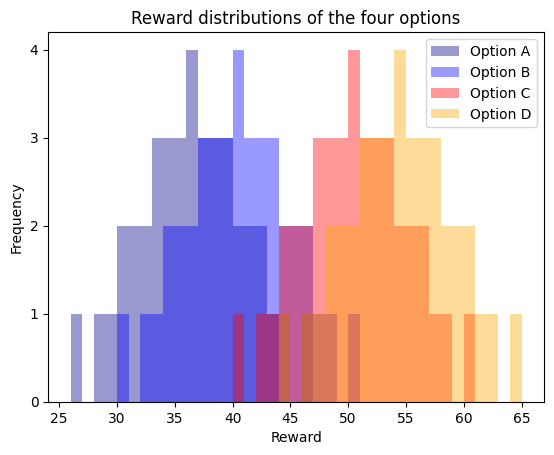

In [4]:
option_A_rewards = [26, 28, 29, 30, 30, 31, 31, 32, 32, 33, 
                    33, 33, 34, 34, 34, 35, 35, 35, 36, 36,
                    36, 36, 37, 37, 37, 38, 38, 38, 39, 39, 
                    39, 40, 40, 41, 41, 42, 42, 43, 44, 46]

option_B_rewards = [30, 32, 33, 34, 34, 35, 35, 36, 36, 37, 
                    37, 37, 38, 38, 38, 39, 39, 39, 40, 40, 
                    40, 40, 41, 41, 41, 42, 42, 42, 43, 43, 
                    43, 44, 44, 45, 45, 46, 46, 47, 48, 50]

option_C_rewards = [40, 42, 43, 44, 44, 45, 45, 46, 46, 47, 
                    47, 47, 48, 48, 48, 49, 49, 49, 50, 50, 
                    50, 50, 51, 51, 51, 52, 52, 52, 53, 53, 
                    53, 54, 54, 55, 55, 56, 56, 57, 58, 60]

option_D_rewards = [44, 46, 47, 48, 48, 49, 49, 50, 50, 51, 
                    51, 51, 52, 52, 52, 53, 53, 53, 54, 54, 
                    54, 54, 55, 55, 55, 56, 56, 56, 57, 57, 
                    57, 58, 58, 59, 59, 60, 60, 61, 62, 64]

PlotRewards(option_A_rewards,option_B_rewards,option_C_rewards,option_D_rewards)


In [5]:
#Define number of trials
n_trials = 20

task = {
    "n_trials": n_trials,
    "option_1_rewards": option_A_rewards,
    "option_2_rewards": option_B_rewards,
    "option_3_rewards": option_C_rewards,
    "option_4_rewards": option_D_rewards,
    "trial_class": {
        "trials_2_options": [[1,4],[1,3],[2,4],[2,3],[1,2],[3,4]], 
        "trials_3_options": [[1,3,4],[2,3,4],[1,2,3],[1,2,4]]
    },
    "experiment_trials": [],
}

metadata = {
    "eam_model": "lca",
    "drift_rate_model": "q_mean", #"q_cv" "q_cv_unc_bonus"
    "learning_model": "delta",#"bmt",
    "n_par": 50
}

theta = {
    'lca': {
        'a': 1,
        'ndt': 0.3,
        'leak': -0.5,
        'inh': -1.5,#-1.3,
        'offset':0.1,
        'noise_std': 0.1,      
    },
    
    'race': {
        'ndt': 0.3,
        'a': 1
    },
    
    'q_mean': {
        'v_mod': 0.01,
        'v_mod_eng': [0.015,0.01,0.005],       
    },
    
    'q_cv': {
        'v_mod': 0.01,
        'v_mod_eng': [0.015,0.01,0.005],       
    },
    
    'q_cv_unc_bonus': {
        'alpha': 0.005,
        'beta': 0.005
    },
    
    'delta': {
        'lr': 0.09,
    },
    
    'bmt': {
        'prior_means':[0,0,0,0],
        'prior_vars':[1000,1000,1000,1000],
        'error_vars': [25,25,25,25]
    }
}


In [6]:
# Generate trials
experiment_trials = []

for p in range(metadata['n_par']):
    experiment_trials.append(Generate_trials(task,0))
    
task['experiment_trials'] = experiment_trials

In [7]:
model = RLEAM(metadata,theta,task)

In [8]:
model.PlayMultiArmedBandit()

Option chosen: E
Reward: 54
Total reward: 1015
GAME ENDED


## Simulation of an Evidence Accumulator Model: The Leaky Competing Accumulator (LCA)

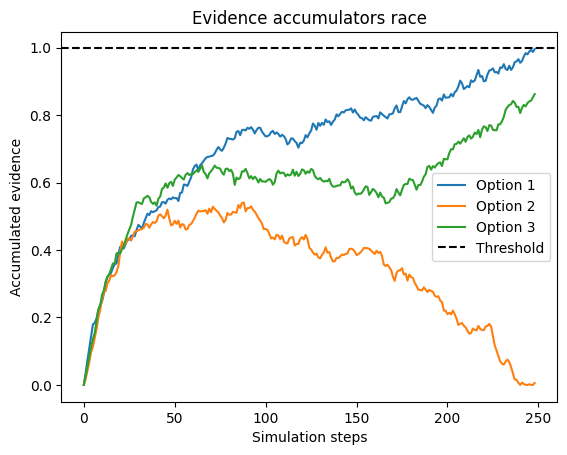

In [9]:
#Define information for the simulations (metadata)
metadata = {'n_alternatives':3, 'n_sims': 10000,'dt':0.01, 'max_t':80,'tqdm': True}
#metadata = {'n_alternatives':2, 'n_sims': 100000,'dt':0.1, 'max_t':80, 'tqdm': True}

#Define parameters of the model
theta = {'a':1,'noise_std':0.1,'leak':-1,'inh':-2,'offset': 0.02,'ndt':0.3,'i0':0.99,'i1':1.1,'i2':1}
#theta = {'a':1,'noise_std':0.1,'leak':-1,'inh':-2, 'offset':0.02,'ndt':0.3,'i0':1.1,'i1':1} # No lels than 0.3

#Build model
model = LCA(metadata,theta)

#Plot the race
model.plot_race()

## Experiment 1: The effect of outcome value differences and number of options on cognitive load

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:04<00:00, 2372.46it/s]


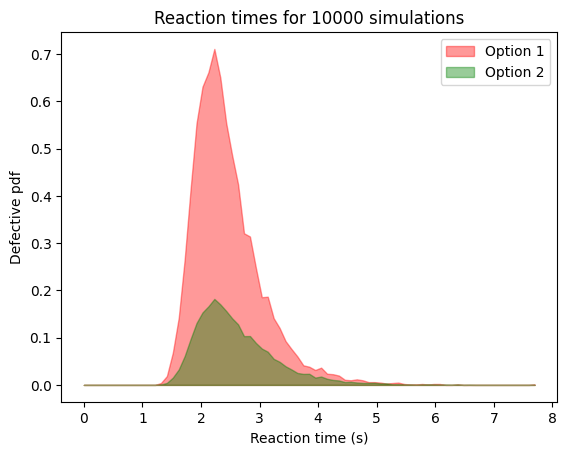

Mean reaction time: 2.65982 s


In [10]:
#Set the number of alternatives
metadata['n_alternatives'] = 2

#Set the number of simulations
metadata['n_sims'] = 10000

metadata['dt'] = 0.1

#Define parameters of the model
# Inputs should not be smaller than 0.3
theta = {'a':1,'noise_std':0.1,'leak':-1,'inh':-3,'offset': 0.02,'ndt':0.3,'i0':1.1,'i1':1} 

#Build model
model = LCA(metadata,theta)

#Plot reaction times from n simulations
model.plot_simulations()

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1472.09it/s]


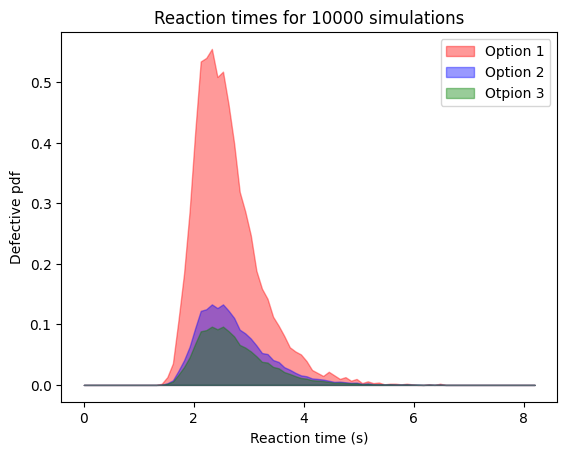

Mean reaction time: 2.8649 s


In [11]:
#Set the number of alternatives
metadata['n_alternatives'] = 3


#Define parameters of the model
theta = {'a':1,'noise_std':0.1,'leak':-1,'inh':-3,'offset': 0.02,'ndt':0.3,'i0':1.1,'i1':1,'i2':0.99}

#Build model
model = LCA(metadata,theta)

#Plot reaction times from n simulations
model.plot_simulations()

## Experiment 2: The effect of learning on cognitive load

#### Set models, parameters, number of participants and trials

In [12]:
# Change the number of trials
task['n_trials'] = 140

# Set models and number of participants
metadata = {
    "eam_model": "lca",
    "drift_rate_model": "q_mean", #"q_cv" "q_cv_unc_bonus"
    "learning_model": "delta",#"bmt",
    "n_par": 50
}

theta = {
    'lca': {
        'a': 1,
        'ndt': 0.3,
        'leak': -0.5,
        'inh': -1.5,#-1.3,
        'offset':0.1,
        'noise_std': 0.1,      
    },
    
    'q_mean': {
        'v_mod': 0.01,
        'v_mod_eng': [0.015,0.01,0.005],       
    },
    
    'q_cv': {
        'v_mod': 0.01,
        'v_mod_eng': [0.015,0.01,0.005],       
    },
    
    'q_cv_unc_bonus': {
        'alpha': 0.005,
        'beta': 0.005
    },
    
    'q_cv_mean_bonus': {
        'alpha': 0.005,
        'beta': 0.005
    },
    
    
    'delta': {
        'lr': 0.09,
    },
    
    'bmt': {
        'prior_means':[0,0,0,0],
        'prior_vars':[1000,1000,1000,1000],
        'error_vars': [25,25,25,25]
    }
}

#### Generate trials

In [13]:
# Generate trials
experiment_trials = []

for p in range(metadata['n_par']):
    experiment_trials.append(Generate_trials(task,2))
    
task['experiment_trials'] = experiment_trials

#### Run simulations

In [14]:
# Build model
model = RLEAM(metadata,theta,task)

# Perform simulations
sim_out = model.simulate()

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:40<00:00,  1.23it/s]


#### Simulation results

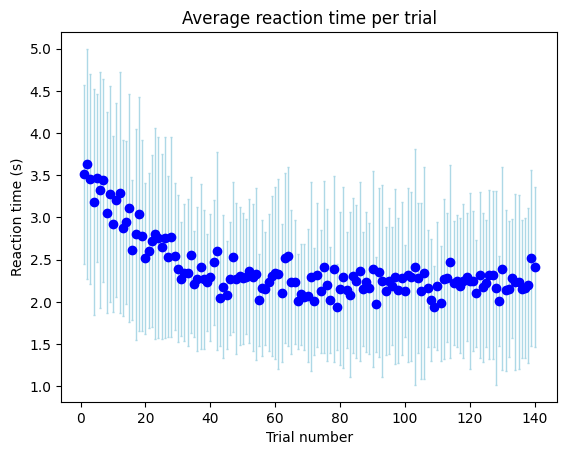

In [15]:
model.plot_average_rt_per_trial(sim_out)

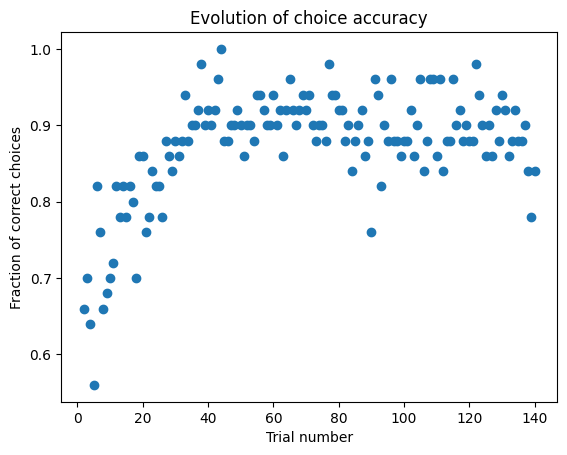

In [16]:
model.plot_choice_accuracy(sim_out)

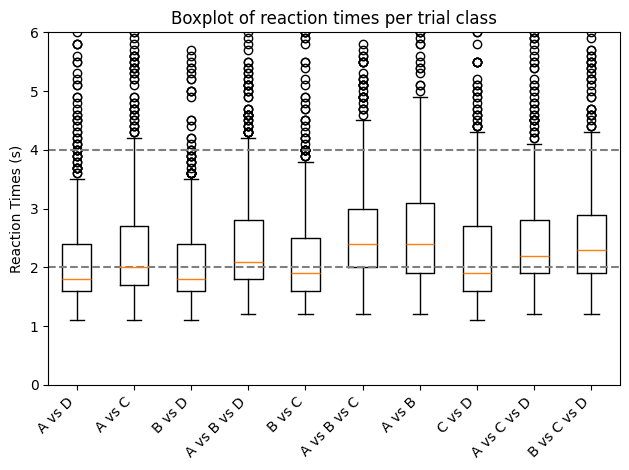

In [17]:
model.boxplot_rt_per_trial_class(sim_out)

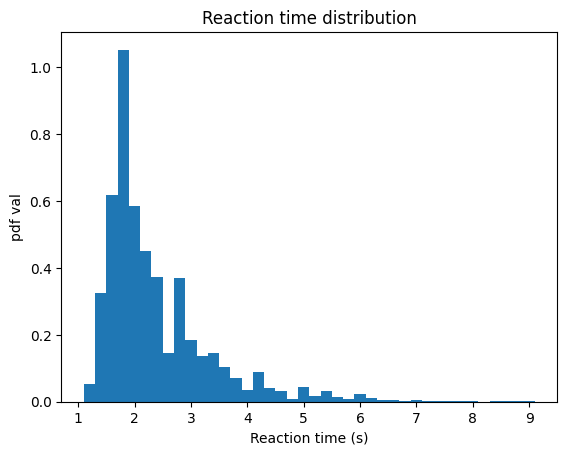

In [18]:
plt.hist(sim_out['rts'].flatten(),bins = 40, density = True)
plt.xlabel("Reaction time (s)")
plt.ylabel("pdf val")
plt.title("Reaction time distribution")
plt.show()

# Experiment 3: The role of uncertainty

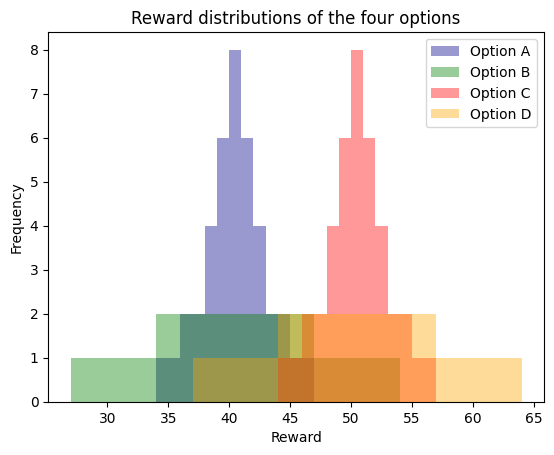

In [24]:

option_A_rewards = [34,35,36,36,37,37,38,38,38,38,39,39,39,39,39,39,40,40,40,40,
                    40,40,40,40,41,41,41,41,41,41,42,42,42,42,43,43,44,44,45,46]

option_B_rewards = [27,28,29,30,31,32,33,34,34,35,35,36,36,37,37,38,38,39,39,40,
                    40,41,41,42,42,43,43,44,44,45,45,46,46,47,48,49,50,51,52,53]

option_C_rewards = [50,55,49,51,56,53,47,52,53,40,56,46,55,47,54,52,43,50,51,50, 
                    60,48,48,48,53,46,42,52,50,57,47,58,51,44,49,45,54,44,45,49]

for i in range(40):
    option_C_rewards[i] = option_A_rewards[i]+ 10
    


option_D_rewards =  [37,38,39,40,41,42,43,44,44,45,45,46,46,47,47,48,48,49,49,50,
                    50,51,51,52,52,53,53,54,54,55,55,56,56,57,58,59,60,61,62,63]

#print(np.sqrt((np.std(option_1_rewards)**2)-(np.std(option_2_rewards)**2)))
#print(np.sqrt(np.std(option_3_rewards)**2 - np.std(option_4_rewards)**2))
#print(np.std(option_1_rewards) + np.std(option_3_rewards))
#print(np.std(option_1_rewards) + np.std(option_4_rewards))
#print(np.std(option_2_rewards) + np.std(option_4_rewards))
#print(np.std(option_2_rewards) + np.std(option_3_rewards))

#print(np.std(option_1_rewards) + np.std(option_2_rewards))
#print(np.std(option_3_rewards) + np.std(option_4_rewards))

#Define bins
bins_A = list(range(min(option_A_rewards), max(option_A_rewards) + 2))
bins_B = list(range(min(option_B_rewards), max(option_B_rewards) + 2))
bins_C = list(range(min(option_C_rewards), max(option_C_rewards) + 2))
bins_D = list(range(min(option_D_rewards), max(option_D_rewards) + 2))


#Plot histogram
plt.hist(option_A_rewards, bins = bins_A, alpha = 0.4,label = "Option A", color = "darkblue")
plt.hist(option_B_rewards, bins = bins_B, alpha = 0.4,label = "Option B", color = "green")
plt.hist(option_C_rewards, bins = bins_C, alpha = 0.4,label = "Option C", color = "red")
plt.hist(option_D_rewards, bins = bins_D, alpha = 0.4,label = "Option D", color = "orange")

plt.locator_params(axis='y', integer=True)
plt.title("Reward distributions of the four options")
plt.ylabel("Frequency")
plt.xlabel("Reward")
plt.legend()
plt.show()


#### Set models and parameters

In [26]:
metadata = {
    "eam_model": "lca",
    "drift_rate_model": "q_cv_unc_bonus",
    "learning_model": "bmt",
    "n_par": 100
}

theta['q_cv_unc_bonus'] =  {'alpha': 0.01,'beta': 0.001}

theta['bmt'] = {
        'prior_means':[0,0,0,0],
        #'prior_mins': [np.mean(option_1_rewards),
        #               np.mean(option_2_rewards),
        #               np.mean(option_3_rewards),
        #               np.mean(option_4_rewards)],
        'prior_vars': [1000,1000,1000,1000],
        #'prior_vars':[np.std(option_1_rewards)**2,
        #              np.std(option_2_rewards)**2,
        #              np.std(option_3_rewards)**2,
        #              np.std(option_4_rewards)**2],
        #'error_vars': [25,25,25,25]
        'error_vars': [np.std(option_A_rewards)**2,
                       np.std(option_B_rewards)**2,
                       np.std(option_C_rewards)**2,
                       np.std(option_D_rewards)**2]
        #'error_vars': [25000,25000,25000,25000]
    }

theta['lca']['inh'] = -1.5

task = {
    "n_trials":160,#160,
    "option_1_rewards": option_A_rewards,
    "option_2_rewards": option_B_rewards,
    "option_3_rewards": option_C_rewards,
    "option_4_rewards": option_D_rewards,
    "trial_class": {
        "trials_2_options": [[1,4],[1,3],[2,4],[2,3],[1,2],[3,4]], 
        "trials_3_options": [[1,3,4],[2,3,4],[1,2,3],[1,2,4]]
    },
    "experiment_trials": [],
}


#### Generate trials

In [27]:
experiment_trials = []

for p in range(metadata['n_par']):
    experiment_trials.append(Generate_trials(task,3))
    
task['experiment_trials'] = experiment_trials

#### Run simulations

In [28]:
# Build model
model = RLEAM(metadata,theta,task)

#Perform simulations
sim_out_exp_3 = model.simulate()

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:07<00:00,  1.47it/s]


#### Simulation results

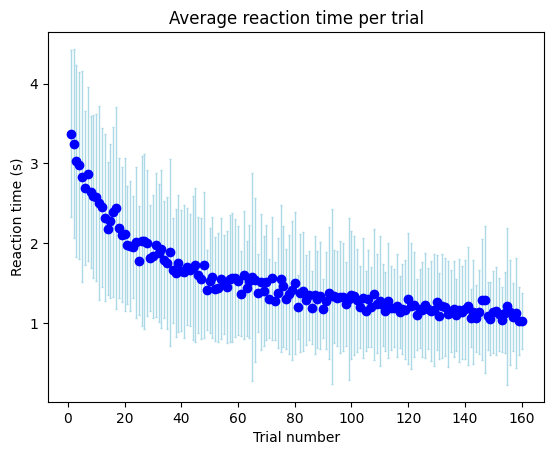

In [29]:
model.plot_average_rt_per_trial(sim_out_exp_3)

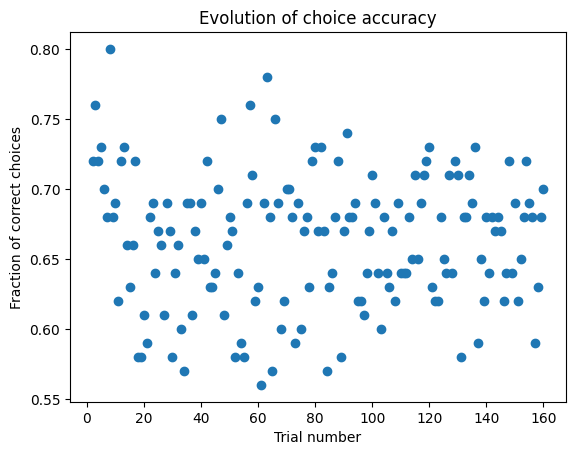

In [30]:
model.plot_choice_accuracy(sim_out_exp_3)

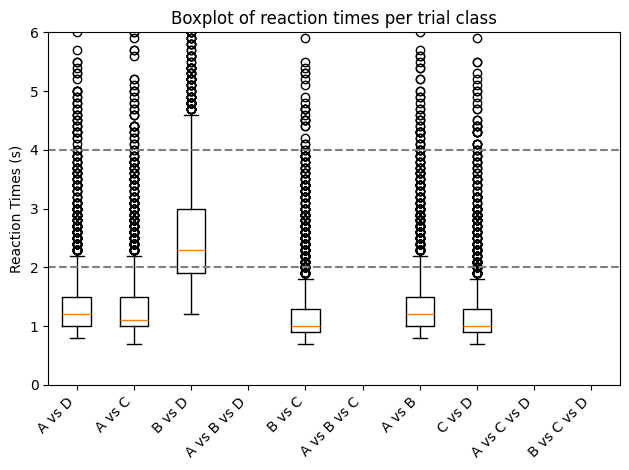

In [31]:
model.boxplot_rt_per_trial_class(sim_out_exp_3)

# Experiment 2b: The role of relative uncertainty

In [ ]:
# Build model
model = RLEAM(metadata,theta,task)

#Perform simulations
sim_out_exp_2b = model.simulate()

In [ ]:
model.PlotChoiceAccuracy(sim_out_exp_2b)

In [ ]:
model.plot_average_rt_per_trial(sim_out_exp_2b)

In [ ]:
model.boxplot_rt_per_trial_class(sim_out_exp_2b)

# Extra

In [ ]:
plt.plot(sim_out_exp_2b['q_vals'][:,0], label = "Option 1")
plt.plot(sim_out_exp_2b['q_vals'][:,1], label = "Option 2")
plt.plot(sim_out_exp_2b['q_vals'][:,2], label = "Option 3")
plt.plot(sim_out_exp_2b['q_vals'][:,3], label = "Option 4")
plt.xlabel("Q vals")
plt.legend()
plt.show()

# Old experiment

In [ ]:
option_1_rewards = [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 
                    35, 36, 36, 37, 37, 38, 38, 39, 39, 40,
                    40, 41, 41, 42, 42, 43, 43, 44, 44, 45,
                    45, 46, 47, 48, 49, 50, 51, 52, 53, 54]

option_2_rewards = [36, 50, 37, 42, 41, 39, 38, 40, 35, 40, 
                    43, 37, 39, 47, 34, 35, 46, 42, 39, 41, 
                    43, 36, 48, 40, 43, 38, 45, 44, 40, 46, 
                    45, 38, 30, 33, 41, 32, 34, 42, 37, 44]

option_3_rewards = [36, 37, 38, 39, 40, 41, 42, 43, 44, 45,
                    45, 46, 46, 47, 47, 48, 48, 49, 49, 50,
                    50, 51, 51, 52, 52, 53, 53, 54, 54, 55, 
                    55, 56, 57, 58, 59, 60, 61, 62, 63, 64]

option_4_rewards = [50, 55, 49, 51, 56, 53, 47, 52, 53, 40, 
                    56, 46, 55, 47, 54, 52, 43, 50, 51, 50, 
                    60, 48, 48, 48, 53, 46, 42, 52, 50, 57, 
                    47, 58, 51, 44, 49, 45, 54, 44, 45, 49]

#option_2_rewards = [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 
#                   35, 36, 36, 37, 37, 38, 38, 39, 39, 40,
#                   40, 41, 41, 42, 42, 43, 43, 44, 44, 45,
#                   45, 46, 47, 48, 49, 50, 51, 52, 53, 54]

option_4_rewards = [34,35,36,36,37,37,38,38,38,38,39,39,39,39,39,39,40,40,40,40,
                    40,40,40,40,41,41,41,41,41,41,42,42,42,42,43,43,44,44,45,46]



option_3_rewards = [32,34, 35,36,36,37,37,37,38,38,38,38,39, 39, 39, 39, 39, 40, 40, 40, 40, 40, 40, 41, 41, 41, 
                    41, 41,42,42,42,42,43,43,43,44,44,45,46,48]

bins_1 = list(range(min(option_1_rewards), max(option_1_rewards) + 2))
bins_2 = list(range(min(option_2_rewards), max(option_2_rewards) + 2))
bins_3 = list(range(min(option_3_rewards), max(option_3_rewards) + 2))
bins_4 = list(range(min(option_4_rewards), max(option_4_rewards) + 2))


#Plot histogram
plt.hist(option_1_rewards, bins = bins_1, alpha = 0.4,label = "Option 1", color = "darkblue")
plt.hist(option_2_rewards, bins = bins_2, alpha = 0.4,label = "Option 2", color = "blue")
plt.hist(option_3_rewards, bins = bins_3, alpha = 0.4,label = "Option 3", color = "red")
plt.hist(option_4_rewards, bins = bins_4, alpha = 0.4,label = "Option 4", color = "orange")

plt.locator_params(axis='y', integer=True)
plt.title("Reward distributions of the four options")
plt.ylabel("Frequency")
plt.xlabel("Reward")
plt.legend()
plt.show()

print("RU (1 vs 4): "+str(np.std(option_1_rewards)-np.std(option_4_rewards)))
print("RU (1 vs 3): "+str(np.std(option_1_rewards)-np.std(option_3_rewards)))
print("RU (1 vs 2): "+str(np.std(option_1_rewards)-np.std(option_2_rewards)))
print("RU (2 vs 4): "+str(np.std(option_2_rewards)-np.std(option_4_rewards)))

print("RU (2 vs 3): "+str(np.std(option_2_rewards)-np.std(option_3_rewards)))
print("RU (3 vs 4): "+str(np.std(option_3_rewards)-np.std(option_4_rewards)))


print("TU (1 vs 4): "+str(np.std(option_1_rewards)+np.std(option_4_rewards)))
print("TU (1 vs 3): "+str(np.std(option_1_rewards)+np.std(option_3_rewards)))
print("TU (1 vs 2): "+str(np.std(option_1_rewards)+np.std(option_2_rewards)))
print("TU (2 vs 4): "+str(np.std(option_2_rewards)+np.std(option_4_rewards)))

print("TU (2 vs 3): "+str(np.std(option_2_rewards)+np.std(option_3_rewards)))
print("TU (3 vs 4): "+str(np.std(option_3_rewards)+np.std(option_4_rewards)))

In [ ]:
metadata = {
    "eam_model": "lca",
    "drift_rate_model": "q_mean_unc_bonus",
    "learning_model": "bmt",
    "n_par": 50
}

theta['q_mean_unc_bonus'] =  {'alpha': 0.01,'beta': 0.0001}

theta['bmt'] = {
        'prior_mins':[0,0,0,0],
        'prior_vars':[1000,1000,1000,1000],
        'error_vars': [25,25,25,25]
    }

task = {
    "n_trials":140,
    "option_1_rewards": option_1_rewards,
    "option_2_rewards": option_2_rewards,
    "option_3_rewards": option_3_rewards,
    "option_4_rewards": option_4_rewards,
    "trial_class": {
        "trials_2_options": [[1,4],[1,3],[2,4],[2,3],[1,2],[3,4]], 
        "trials_3_options": [[1,3,4],[2,3,4],[1,2,3],[1,2,4]]
    },
    "experiment_trials": [],
}